<div align="center">
  <span style="color: red; font-size: 4em; font-weight: bold;">
    Question 8
  </span>
</div>

In [23]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from ISLP import load_data
from matplotlib.pyplot import subplots
from ISLP.models import summarize, ModelSpec as MS
from statsmodels.stats.anova import anova_lm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

## (a)

In [24]:
auto = load_data('Auto')
auto =auto.reset_index()
auto.head()

,name,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
0,chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
1,buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
2,plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
3,amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
4,ford torino,17.0,8,302.0,140,3449,10.5,70,1


In [25]:
X = pd.DataFrame({'Intercept': np.ones(auto.shape[0]),
                  'horsepower': auto['horsepower']})
X.head()

,Intercept,horsepower
0,1.0,130
1,1.0,165
2,1.0,150
3,1.0,150
4,1.0,140


In [26]:
Y = auto['mpg']
model = sm.OLS(Y, X)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     599.7
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           7.03e-81
Time:                        19:01:32   Log-Likelihood:                -1178.7
No. Observations:                 392   AIC:                             2361.
Df Residuals:                     390   BIC:                             2369.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     39.9359      0.717     55.660      0.000      38.525      41.347
horsepower    -0.1578      0.006    -24.489      0.000      -0.171      -0.145
==============================================================================
Omnibus:                       16.432   Durbin-Watson:                   0.920
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               17.305
Skew:                           0.492   Prob(JB):                     0.000175
Kurtosis:                       3.299   Cond. No.                         322.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [27]:
results.params

Intercept     39.935861
horsepower    -0.157845
dtype: float64

In [28]:
newX = pd.DataFrame({'Intercept': 1,
                     'horsepower': [98]})
predicted = results.predict(newX)
predicted

0    24.467077
dtype: float64

In [29]:
predictions = results.get_prediction(newX)
pred_summary = predictions.summary_frame(alpha=0.05)
pred_summary
# mean_ci_lower & upper: confidence interval and obs_ci_lower & upper: prediction interval

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,24.467077,0.251262,23.973079,24.961075,14.809396,34.124758


## (b)

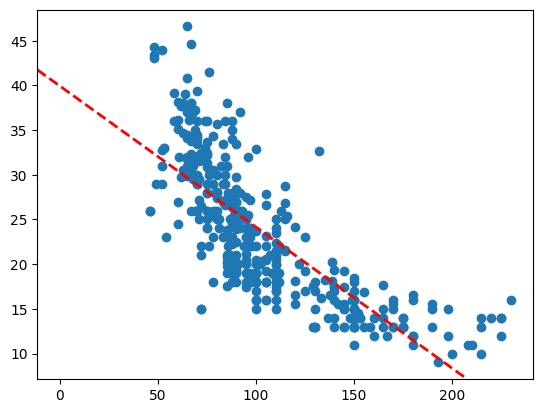

In [30]:
fig, ax = subplots()
ax.scatter(auto['horsepower'], auto['mpg'])
ax.axline((0, results.params.iloc[0]),
          slope = results.params.iloc[1],
          color = 'red',
          ls = '--',
          linewidth = 2)


## (c)

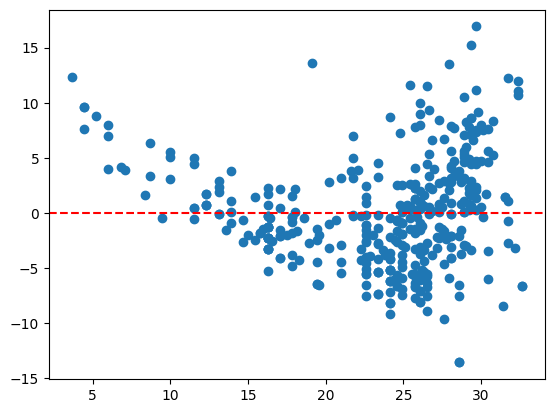

In [31]:
ax = subplots()[1]
ax.scatter(results.fittedvalues, results.resid)
ax.axhline(0, color='red', linestyle='--')



this residual plot shows pattern of shape u, so non-linear relationship might exist between them, so leverage matrix is also plotted in next graph


np.int64(115)

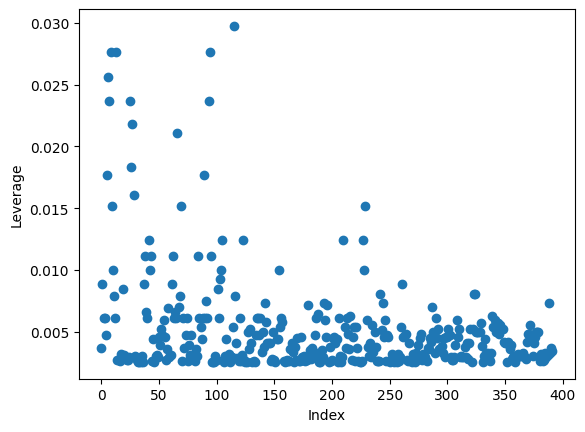

In [32]:
infl = results.get_influence()
ax = subplots()[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)


this shows this is well behaved observation with predictor values that don't stand out.

<div align="center">
  <span style="color: red; font-size: 4em; font-weight: bold;">
    Question 9
  </span>
</div>

## (a)

In [33]:
Auto = load_data('Auto')
Auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1


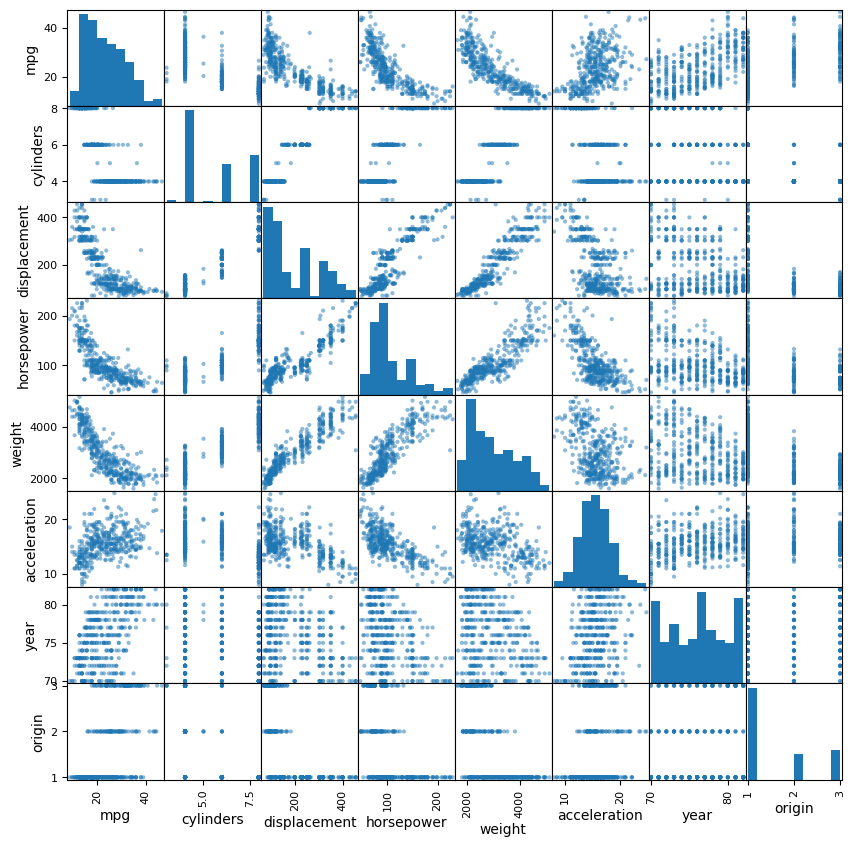

In [34]:
pd.plotting.scatter_matrix(Auto, figsize=(10,10));

## (b)

In [35]:
Auto.corr(numeric_only=True)

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


## (c)

In [36]:
list1 = Auto.columns.drop('mpg')
X = MS(list1).fit_transform(Auto)
Y = Auto['mpg']
model = sm.OLS(Y, X)
results = model.fit()
summarize(results)


,coef,std err,t,P>|t|
intercept,-17.2184,4.644,-3.707,0.000
cylinders,-0.4934,0.323,-1.526,0.128
displacement,0.0199,0.008,2.647,0.008
horsepower,-0.0170,0.014,-1.230,0.220
weight,-0.0065,0.001,-9.929,0.000
acceleration,0.0806,0.099,0.815,0.415
year,0.7508,0.051,14.729,0.000
origin,1.4261,0.278,5.127,0.000


### (i)

In [37]:
results1 = smf.ols('Y~X', data=Auto).fit()
anova_lm(results1)


,df,sum_sq,mean_sq,F,PR(>F)
X,8.0,19576.082069,2447.010259,220.979533,1.326882e-138
Residual,384.0,4252.212530,11.073470,NaN,NaN


### (ii)

displacement, weight, year and origin seems to have significant relationship to mpg as they have p value close to 0

### (iii)

if all other predictors are constant then when year is increased by 1, the mpg of car will increase by 0.75 meaning more recent the car manufactured more efficiency they carry

## (d)

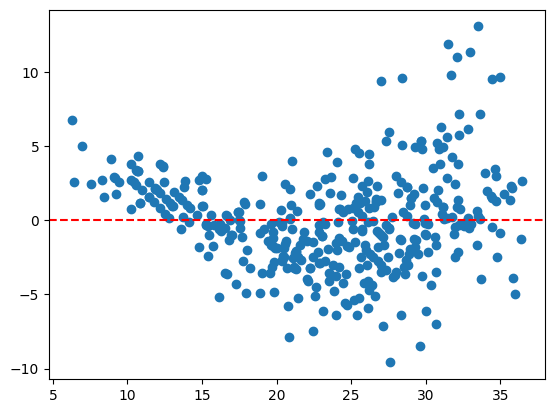

In [38]:
# residual plot
ax = subplots()[1]
ax.scatter(results1.fittedvalues, results1.resid)
ax.axhline(0, color='red', linestyle='--')

<Axes: >

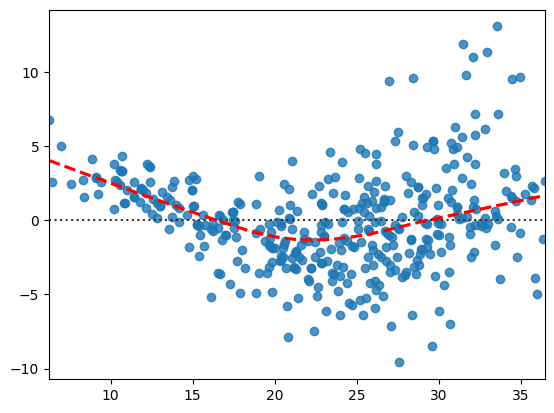

In [39]:
import seaborn as sns
sns.residplot(x=results1.fittedvalues, y=results1.resid, lowess=True,
              line_kws={'color': 'red', 'linestyle': '--'})


The curve suggests there is non-linearity relationship among the predictors

Text(0, 0.5, 'Studentized Residuals')

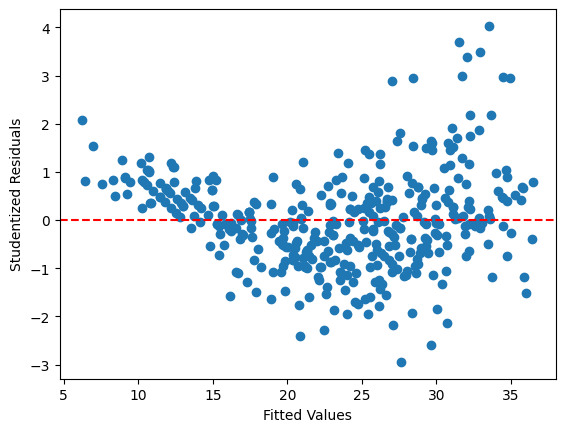

In [40]:
# Studentized Residual Plot
infl = results.get_influence()
stud_resid = infl.resid_studentized_external
ax = subplots()[1]
ax.scatter(results1.fittedvalues, stud_resid)
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel('Fitted Values')
ax.set_ylabel('Studentized Residuals')

In [41]:
# observations with studentized residuals greater than 3 in absolute value are often considered outliers
outliers = np.where(np.abs(stud_resid) > 3)[0]
print("Outliers (index):", outliers)

Outliers (index): [242 320 323 324]


np.int64(13)

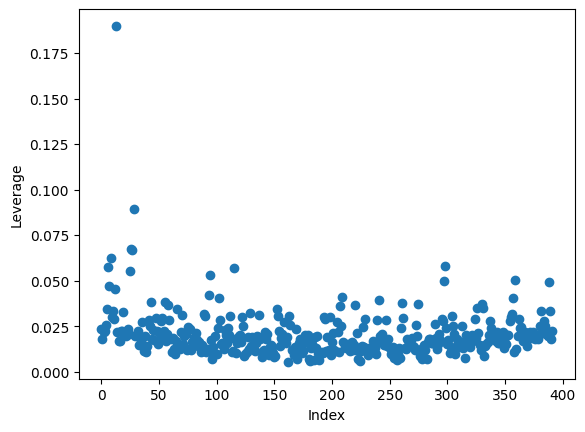

In [42]:
# leverage plot
ax = subplots()[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)

the avg leverage value (p+1)/n is (8+1)/392 = 0.023 and here at index 13, leverage value is more than 0.175 which is way higher than avg value so it shows it may be dangerous and might invalidate the entrire model fit

In [43]:
Auto.corr()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


## (e)

In [44]:
# use smf.ols for easy fit of model
result2 = smf.ols('mpg ~ year*displacement', data=Auto).fit()
result2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.774
Model:                            OLS   Adj. R-squared:                  0.772
Method:                 Least Squares   F-statistic:                     441.7
Date:                Sat, 14 Mar 2026   Prob (F-statistic):          1.04e-124
Time:                        19:01:37   Log-Likelihood:                -1070.1
No. Observations:                 392   AIC:                             2148.
Df Residuals:                     388   BIC:                             2164.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept           -72.8784      8.368     -8.709      0.000     -89.330     -56.427
year                  1.4077      0.110     12.779      0.000       1.191       1.624
displacement          0.2523      0.041      6.216      0.000       0.173       0.332
year:displacement    -0.0041      0.001     -7.482      0.000      -0.005      -0.003
==============================================================================
Omnibus:                       42.582   Durbin-Watson:                   1.373
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               89.987
Skew:                           0.593   Prob(JB):                     2.88e-20
Kurtosis:                       5.026   Cond. No.                     7.32e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.32e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [45]:
result3 = smf.ols('mpg ~ weight + horsepower*displacement + year', data=Auto).fit()
summarize(result3)

,coef,std err,t,P>|t|
Intercept,-3.8049,3.742000,-1.017,0.31
weight,-0.0040,0.001000,-7.231,0.00
horsepower,-0.1624,0.017000,-9.815,0.00
displacement,-0.0630,0.007000,-8.556,0.00
horsepower:displacement,0.0005,0.000043,11.345,0.00
year,0.7466,0.045000,16.420,0.00


## (f)

In [46]:
model2 = smf.ols('mpg ~ np.square(horsepower) + horsepower + weight', data=Auto)
results2 = model2.fit()
summarize(results2)

,coef,std err,t,P>|t|
Intercept,55.9864,1.649,33.953,0.0
np.square(horsepower),0.0008,0.000,7.040,0.0
horsepower,-0.2838,0.035,-8.067,0.0
weight,-0.0045,0.001,-8.809,0.0


In [47]:
model3 = smf.ols('mpg~ np.log(weight) + year + weight', data=Auto)
results3 = model3.fit()
summarize(results3)

,coef,std err,t,P>|t|
Intercept,284.2873,29.393,9.672,0.0
np.log(weight),-43.5906,4.259,-10.235,0.0
year,0.8287,0.045,18.620,0.0
weight,0.0078,0.001,5.473,0.0


In [48]:
model4 = smf.ols('mpg ~ year + np.sqrt(year) + displacement', data=Auto)
results4 = model4.fit()
summarize(results4)

,coef,std err,t,P>|t|
Intercept,2379.2140,355.748,6.688,0.0
year,32.3055,4.688,6.890,0.0
np.sqrt(year),-550.8847,81.699,-6.743,0.0
displacement,-0.0508,0.002,-25.875,0.0


<div align="center">
  <span style="color: red; font-size: 4em; font-weight: bold;">
    Question 10
  </span>
</div>

In [49]:
carseats = load_data('Carseats')
print(carseats.columns)
carseats.head()

Index(['Sales', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price',
       'ShelveLoc', 'Age', 'Education', 'Urban', 'US'],
      dtype='object')


,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


## (a)

In [50]:
model = smf.ols('Sales ~ Price + Urban + US', data=carseats)
result = model.fit()
summarize(result)

,coef,std err,t,P>|t|
Intercept,13.0435,0.651,20.036,0.000
Urban[T.Yes],-0.0219,0.272,-0.081,0.936
US[T.Yes],1.2006,0.259,4.635,0.000
Price,-0.0545,0.005,-10.389,0.000


## (b)

The relation betn urban and sales is not significant. The coeff of us is positive which implies that if it is located in us then the sales is bound to increase but it has inverse relation with price, if price is increased by a unit sales is decreased by factor 0.0545.

## (c)

 Sales = 13.045 - 0.0219 * Urban + 1.20060 * US - 0.0545*Price 

 value of urban is 1 if its value is yes and 0 if it is no and same for us

## (d)

we can reject null hypothesis for US and price as their p value is close to 0 but can't reject for Urban.

## (e)

In [51]:
model1 = smf.ols('Sales ~ US + Price', data=carseats)
results1 = model1.fit()
summarize(results1)

,coef,std err,t,P>|t|
Intercept,13.0308,0.631,20.652,0.0
US[T.Yes],1.1996,0.258,4.641,0.0
Price,-0.0545,0.005,-10.416,0.0


## (f)

In [52]:
# we can compare how well the models fit by calculating R² for both models
print(result.rsquared)
print(results1.rsquared)

0.23927539218405547
0.23926288842678567


as we can see both has almost same value but since 2nd model has less predictors so it is optimal one.

## (g)

In [53]:
results1.conf_int(alpha=0.05)

,0,1
Intercept,11.79032,14.271265
US[T.Yes],0.69152,1.707766
Price,-0.06476,-0.044195


## (h)

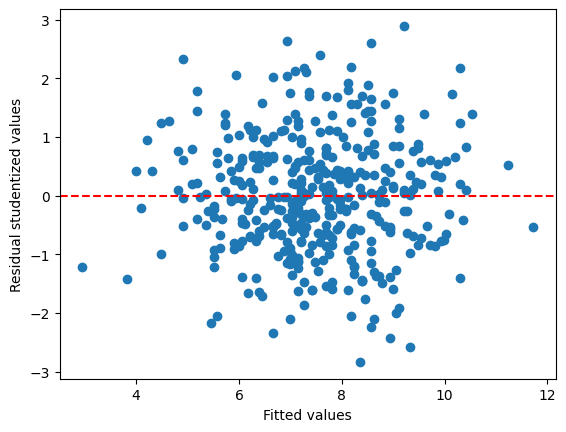

In [54]:
#Studentized Residual Plot
infl = results1.get_influence()
ax = subplots()[1]
ax.scatter(results1.fittedvalues, infl.resid_studentized_external)
ax.set_xlabel('Fitted values')
ax.set_ylabel('Residual studentized values')
ax.axhline(0, c='r', ls='--')

In [55]:
outliers = np.where(np.abs(infl.resid_studentized_external > 3))[0]
print('Outliers(Index): ', outliers)


Outliers(Index):  []


This shows that there are not outliers. We can also check this by calculaing leverage points.

Text(0, 0.5, 'Leverage')

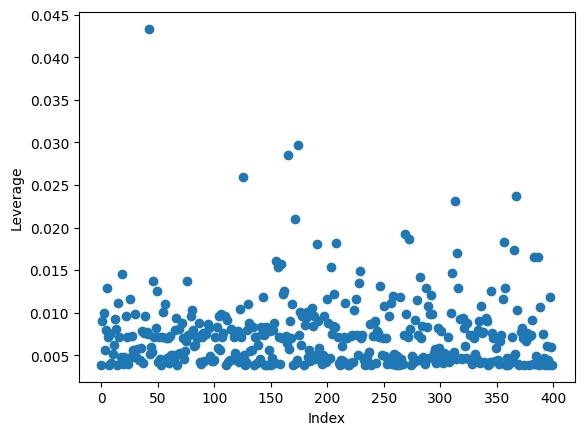

In [56]:
ax = subplots()[1]
Xnew = MS(['Price', 'US']).fit_transform(carseats)
ax.scatter(np.arange(Xnew.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')


To find out threshold for leverage calcualte by using formula (p+1)/n

In [57]:
n = carseats.shape[0]
threshold = 3/n
threshold

0.0075

since threshold value is 0.075, and our highest value of leverage is less than 0.045 so it doesnot show any potential outlier.


<div align="center">
  <span style="color: red; font-size: 4em; font-weight: bold;">
    Question 11
  </span>
</div>

In [58]:
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = 2 * x + rng.normal(size=100)

## (a)

In [59]:
# y onto x
odel = sm.OLS(y, x)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
Intercept,13.0435,0.651,20.036,0.000
Urban[T.Yes],-0.0219,0.272,-0.081,0.936
US[T.Yes],1.2006,0.259,4.635,0.000
Price,-0.0545,0.005,-10.389,0.000


coeff of x is 1.9762 which is ~ 2, which shows it is fitted properly. std error of coeff estimate is 0.117 which shows that estimate of coeff is precise. t-stat is 16.898 which provides evidence that slope is not zero and p value of 0 makes it almost certain to rej null hypothesis.

## (b)

In [60]:
# x onto y
model1 = sm.OLS(x, y)
results1 = model1.fit()
summarize(results1)

,coef,std err,t,P>|t|
x1,0.3757,0.022,16.898,0.0


same results as above

## (c)

both a and b have same t-stat and p value which indicates statistical evidence against null hypothesis(H0). the diff coeff estimates is expected because it is slope which represents change in response for one unit change in predictor.

## (d)

In [61]:
β = np.sum(x*y) / np.dot(x,x)
n = 100
SE = np.sqrt((np.sum(np.square(y-x*β)))/((n-1)*np.dot(x,x)))
#np.dot(x,x) returns sum for x2
tstat = β/SE
tstat
      

np.float64(16.8984170630351)

In [62]:
num = np.sqrt(n-1)*np.sum(x*y)
den = np.dot(x,x)*np.dot(y,y)-np.square(np.sum(x*y))
tstat1 = num / np.sqrt(den)
tstat1

np.float64(16.8984170630351)

## (e)

as seen from eqn 2 we can interchange x and y and still get same result, so it clarifies that t stat value for y onto x and x onto y are same.

## (f)

In [63]:
# y onto x with intercept
df = pd.DataFrame({'x':x, 'y':y})
x1 = MS(df[['x']]).fit_transform(df)
model_i = sm.OLS(y, x1).fit()
summarize(model_i)

,coef,std err,t,P>|t|
intercept,-0.0760,0.101,-0.756,0.451
x,1.9686,0.118,16.734,0.000


In [64]:
#x onto y with intercept
y1 = MS(df[['y']]).fit_transform(df)
model_ii = sm.OLS(x, y1).fit()
summarize(model_ii)

,coef,std err,t,P>|t|
intercept,0.0095,0.044,0.216,0.829
y,0.3763,0.022,16.734,0.000


In [65]:
#alternatively using smf
model_1 = smf.ols('y~x', data=df).fit()
summarize(model_1)

,coef,std err,t,P>|t|
Intercept,-0.0760,0.101,-0.756,0.451
x,1.9686,0.118,16.734,0.000


In [66]:
model_2 = smf.ols('x~y', data=df).fit()
summarize(model_2)

,coef,std err,t,P>|t|
Intercept,0.0095,0.044,0.216,0.829
y,0.3763,0.022,16.734,0.000


<div align="center">
  <span style="color: red; font-size: 4em; font-weight: bold;">
    Question 12
  </span>
</div>

## (a)

The coeff estimate for linear regression without intercept will be same in following condition:
$$\frac{\sum_{i=1}^n x_i^2}{\sum_{i=1}^n x_i y_i} = \frac{\sum_{i=1}^n y_i^2}{\sum_{i=1}^n y_i x_i}
$$
This reduces to :
$$
\sum_{i=1}^n x_i^2 = \sum_{i=1}^n y
$$
in simple terms, estimates are same when sum of squares o fthe observed X is equal to sum of squares of observed Y.

## (b)

In [67]:
# y onto x
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = 2 * x + rng.normal(size=100)
df = pd.DataFrame({'x':x, 'y':y})
model = sm.OLS(y,x).fit()
summarize(model)

,coef,std err,t,P>|t|
x1,1.9762,0.117,16.898,0.0


In [68]:
# x onto y
model1 = sm.OLS(x,y).fit()
summarize(model1)


,coef,std err,t,P>|t|
x1,0.3757,0.022,16.898,0.0


## (c)

In [69]:
y = x[::-1]
model2 = sm.OLS(y,x).fit()
summarize(model2)

,coef,std err,t,P>|t|
x1,-0.0403,0.1,-0.402,0.689


In [70]:
model3 = sm.OLS(x,y).fit()
summarize(model3)

,coef,std err,t,P>|t|
x1,-0.0403,0.1,-0.402,0.689


<div align="center">
  <span style="color: red; font-size: 4em; font-weight: bold;">
    Question 13
  </span>
</div>

## (a-c)

In [71]:
rng = np.random.default_rng(1)
x = rng.normal(size=100)
eps = rng.normal(loc=0, scale=0.5, size=100)
#scale=0.5 sets standard deviation to 0.5 and variance is square of std
y = -1 + 0.5*x + eps
print(y.shape)

(100,)


in this linear model, beta0 is -1 and beta1 is 0.5

## (d)

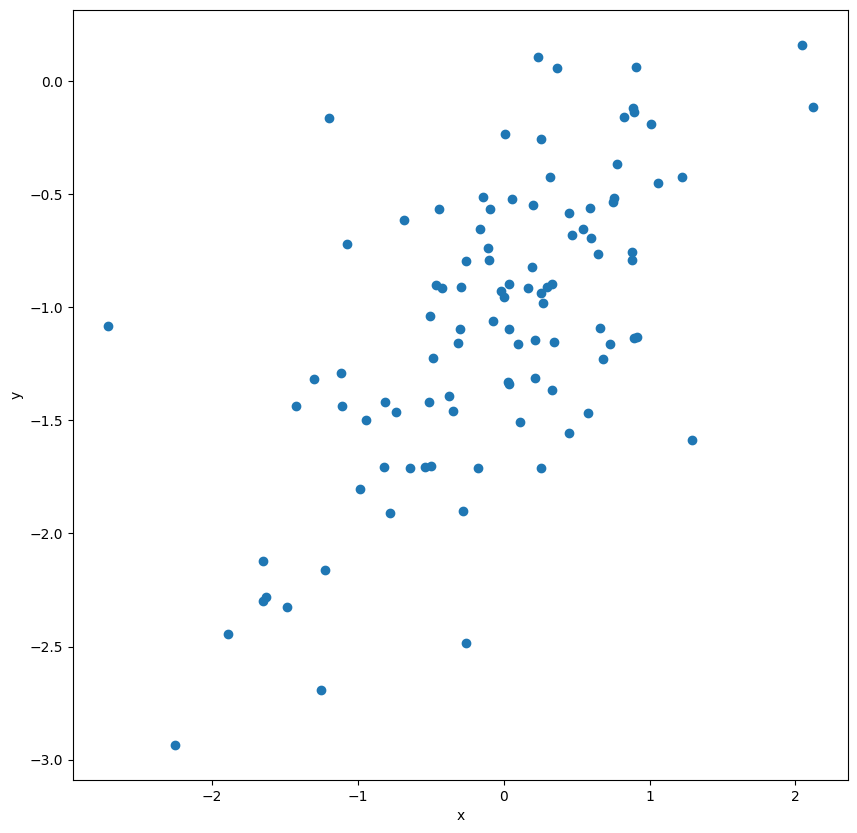

In [72]:
ax = subplots(figsize=(10,10))[1]
ax.scatter(x,y)
ax.set_xlabel('x')
ax.set_ylabel('y');

## (e)

In [73]:
df = pd.DataFrame({'x':x, 'y':y})
model = smf.ols('y~x', data=df)
result = model.fit()
summarize(result)

,coef,std err,t,P>|t|
Intercept,-1.0380,0.050,-20.647,0.0
x,0.4843,0.059,8.233,0.0


intercept change to -1.038 from -1 and slope from 0.5 to 0.4843

## (f)

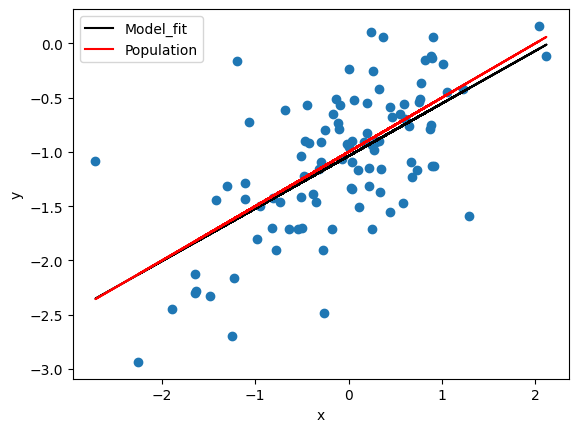

In [74]:
beta0 = result.params.iloc[0]
beta1 = result.params.iloc[1]
y_pred = [beta0 + beta1*xi for xi in x]
y_real = [-1+0.5*xi for xi in x]
plt.scatter(x,y)
plt.plot(x, y_pred, 'black', label='Model_fit')
plt.plot(x, y_real, 'red', label = 'Population')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='upper left')

## (g)


In [75]:
model_poly = smf.ols('y~I(x**2) + x', data=df)
result_poly = model_poly.fit()
summarize(result_poly)

,coef,std err,t,P>|t|
Intercept,-1.0364,0.060,-17.399,0.000
I(x ** 2),-0.0024,0.045,-0.052,0.959
x,0.4831,0.063,7.647,0.000


p value of x^2 shows that there is no significant relation betn y and x^2


## (h)

,coef,std err,t,P>|t|
Intercept,-1.0005,0.009,-112.466,0.0
x1,0.5095,0.010,53.104,0.0


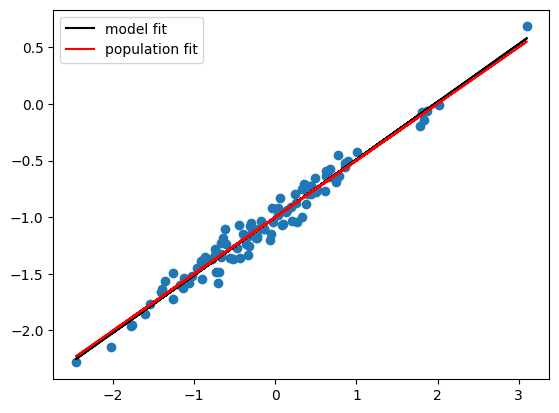

In [76]:
x1 = rng.normal(size=100)
eps1 = rng.normal(scale=0.1, size=100) #var = 0.01
y1 = -1+0.5*x1+eps1
df1 = pd.DataFrame({'x1':x1, 'y1':y1})
model1 = smf.ols('y1~x1', data=df1)
result1 = model1.fit()
beta0 = result1.params.iloc[0]
beta1 = result1.params.iloc[1]
y_pred1 = [beta0 + beta1*xi for xi in x1]
y_real1 = [-1+0.5*xi for xi in x1]
plt.scatter(x1, y1)
plt.plot(x1, y_pred1, 'black', label='model fit')
plt.plot(x1, y_real1, 'red', label='population fit')
plt.legend(loc= 'upper left')
summarize(result1)

## (i)

,coef,std err,t,P>|t|
Intercept,-1.0655,0.102,-10.437,0.0
x2,0.4289,0.112,3.836,0.0


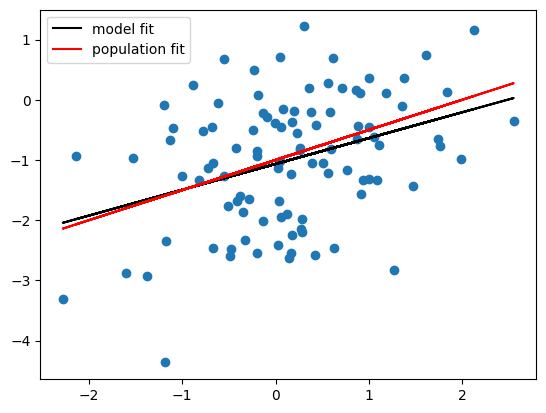

In [77]:
x2 = rng.normal(size=100)
eps2 = rng.normal(scale=0.9, size=100) #var=0.81
y2 = -1+0.5*x2+eps2
df2 = pd.DataFrame({'x2':x2, 'y2':y2})
model2 = smf.ols('y2~x2', data=df2)
result2 = model2.fit()
beta_0 = result2.params.iloc[0]
beta_1 = result2.params.iloc[1]
y_predic = [beta_0+beta_1*xi for xi in x2]
y_reall = [-1+0.5*xi for xi in x2]
plt.scatter(x2,y2)
plt.plot(x2, y_predic, 'black', label='model fit')
plt.plot(x2, y_reall, 'red', label = 'population fit')
plt.legend(loc='upper left')
summarize(result2)

from h and i we can see that if we increase var then std err also increases and the distrubution is also less linear.

## (j)

In [78]:
result.conf_int(alpha=0.05)

,0,1
Intercept,-1.137782,-0.938244
x,0.367565,0.601017


In [79]:
result1.conf_int(alpha=0.05)

,0,1
Intercept,-1.018123,-0.982816
x1,0.490456,0.528535


In [80]:
result2.conf_int(alpha=0.05)

,0,1
Intercept,-1.268052,-0.862892
x2,0.207034,0.650721


from conf interval too we can see that for less var data the interval is small whereas for bigger var interval is large too

<div align="center">
  <span style="color: red; font-size: 4em; font-weight: bold;">
    Question 14
  </span>
</div>

## (a)

In [81]:
rng = np.random.default_rng(10)
x1 = rng.uniform(0, 1, size=100)
x2 = 0.5 * x1 + rng.normal(size=100)/10
y = 2 + 2 * x1 + 0.3 * x2 + rng.normal(size=100)

beta_0 = 2
beta_1 = 2
beta_2 = 0.3

## (b)

In [82]:
np.corrcoef(x1, x2)

array([[1.       , 0.7723245],
       [0.7723245, 1.       ]])

The correlation betn x1 and x2 is 0.7723

Text(0, 0.5, 'x2')

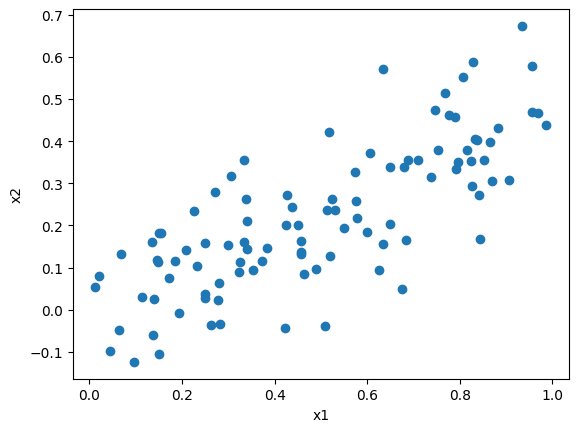

In [83]:
plt.scatter(x1, x2)
plt.xlabel('x1')
plt.ylabel('x2')

## (c)

In [84]:
df = pd.DataFrame({'x1':x1, 'x2':x2, 'y':y})
model = smf.ols('y~x1+x2', data=df)
result = model.fit()
summarize(result)

,coef,std err,t,P>|t|
Intercept,1.9579,0.190,10.319,0.000
x1,1.6154,0.527,3.065,0.003
x2,0.9428,0.831,1.134,0.259


intercept coeff is obtained as 1.9579 which is almost equal to 2, x1 is 1.6154 which is quite less than 2 and for x2 it is obtained to be 0.942 which is much more than 0.3. since t value is small for x2 and p > 0.05 so, we can't reject null hypothesis for x2 but for x1 we can somewhat reject.

## (d)

In [85]:
model1 = smf.ols('y~x1', data=df)
result1 = model1.fit()
summarize(result1)

,coef,std err,t,P>|t|
Intercept,1.9371,0.189,10.242,0.0
x1,2.0771,0.335,6.196,0.0


we can rej null hypothesis.

## (e)

In [86]:
model2 = smf.ols('y~x2', data=df)
result2 = model2.fit()
summarize(result2)

,coef,std err,t,P>|t|
Intercept,2.3239,0.154,15.124,0.0
x2,2.9103,0.550,5.291,0.0


we can rej null hypothesis

## (f)

At glance, it may seems they contradict eachother, but if we dig deep it might be the result of the collinearity among x1 and x2 such that when both of them appears x2 seems to be dismissed but when doing seperately we can't dismiss any of these

## (g)

In [87]:
x1 = np.concatenate ([x1 , [0.1]])
x2 = np.concatenate ([x2 , [0.8]])
y = np.concatenate ([y, [6]])
df2 = pd.DataFrame({'x1':x1, 'x2':x2, 'y':y})
model1 = smf.ols('y~x1+x2', data=df2).fit()
summarize(model1)

,coef,std err,t,P>|t|
Intercept,2.0618,0.192,10.720,0.000
x1,0.8575,0.466,1.838,0.069
x2,2.2663,0.705,3.216,0.002


In [88]:
model2 = smf.ols('y~x1', data=df2).fit()
summarize(model2)

,coef,std err,t,P>|t|
Intercept,2.0739,0.201,10.310,0.0
x1,1.8760,0.358,5.236,0.0


In [89]:
model3 = smf.ols('y~x2', data=df2).fit()
summarize(model3)

,coef,std err,t,P>|t|
Intercept,2.2840,0.151,15.088,0.0
x2,3.1458,0.524,6.008,0.0


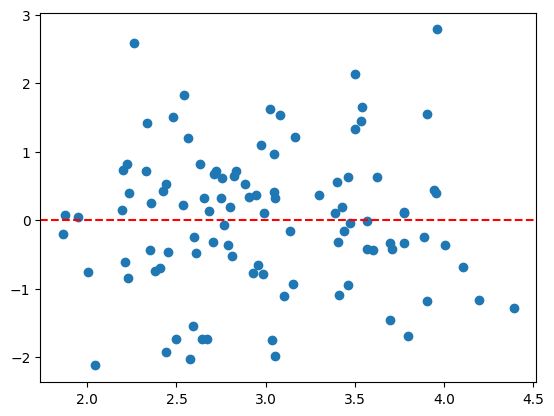

In [90]:
infl = model1.get_influence()
ax = subplots()[1]
ax.scatter(model1.fittedvalues, infl.resid_studentized_external)
ax.axhline(0, c='r', ls='--')

In [91]:
np.where(np.abs(infl.resid_studentized_external > 3))

(array([], dtype=int64),)

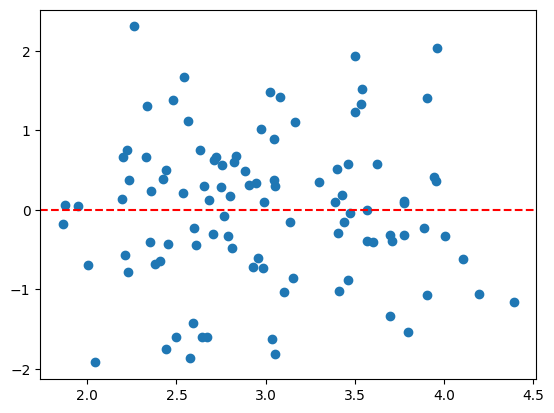

In [92]:
ax1 = subplots()[1]
ax1.scatter(model1.fittedvalues, model1.resid)
ax1.axhline(0, c='r', ls='--')

np.int64(100)

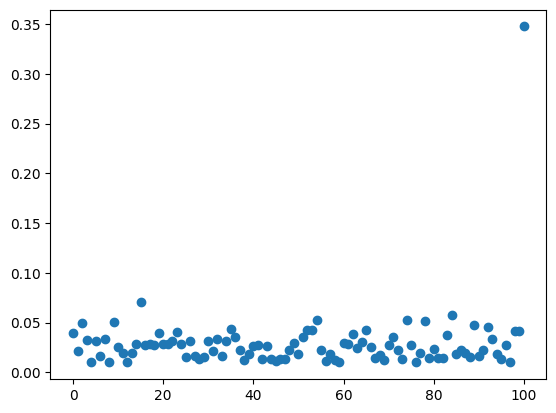

In [93]:
ax2 = subplots()[1]
ax2.scatter(np.arange(x1.shape[0]), infl.hat_matrix_diag)
np.argmax(infl.hat_matrix_diag)

this clearly shows high leverage point at index 100, which are the added values in this question part.

<div align="center">
  <span style="color: red; font-size: 4em; font-weight: bold;">
    Question 15
  </span>
</div>

In [94]:
boston = load_data('Boston')
boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


## (a)

In [95]:
response = 'crim'
results = {}

for predictor in boston.columns:
    if predictor != response:
        formula = f'{response}~{predictor}'
        model1 = smf.ols(formula, data=boston).fit()
        results[predictor] = model1.pvalues.iloc[1] #pvalues returns coeff for both intercept and predictor
        
results
        

{'zn': np.float64(5.5064721076791945e-06),
 'indus': np.float64(1.450348933027281e-21),
 'chas': np.float64(0.20943450153520096),
 'nox': np.float64(3.7517392603567345e-23),
 'rm': np.float64(6.346702984687838e-07),
 'age': np.float64(2.8548693502440745e-16),
 'dis': np.float64(8.519948766926326e-19),
 'rad': np.float64(2.6938443981864414e-56),
 'tax': np.float64(2.357126835256745e-47),
 'ptratio': np.float64(2.9429224473599125e-11),
 'lstat': np.float64(2.6542772314732725e-27),
 'medv': np.float64(1.1739870821943694e-19)}

from above result we can see that besides chas every other predictors are significant

## (b)

In [96]:
pred = '+'.join(boston.columns.drop('crim'))
model2 = smf.ols(f'crim~{pred}', data=boston).fit()
summarize(model2)

,coef,std err,t,P>|t|
Intercept,13.7784,7.082,1.946,0.052
zn,0.0457,0.019,2.433,0.015
indus,-0.0584,0.084,-0.698,0.486
chas,-0.8254,1.183,-0.697,0.486
nox,-9.9576,5.290,-1.882,0.060
rm,0.6289,0.607,1.036,0.301
age,-0.0008,0.018,-0.047,0.962
dis,-1.0122,0.282,-3.584,0.000
rad,0.6125,0.088,6.997,0.000
tax,-0.0038,0.005,-0.730,0.466


The predictors for which we can rej null hypothesis are: <br>
zn, dis, rad, medv

## (c)

Text(0, 0.5, 'multiple')

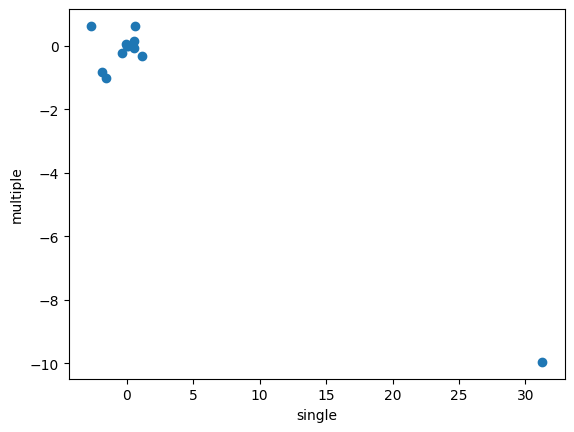

In [97]:
# at first lets store the coeff of model1 in dic

response = 'crim'
coeff = {}
for pred in boston.columns:
    if pred != response:
        formula = f'{response}~{pred}'
        model1 = smf.ols(formula, data=boston).fit()
        coeff[pred] = model1.params.iloc[1]
        
x = list(coeff.values())
#we can directly access coeff of model 2
dummy = summarize(model2)
y = dummy['coef'].iloc[1:].to_list()
plt.scatter(x, y)
plt.xlabel('single')
plt.ylabel('multiple')

## (d)

In [98]:
response = 'crim'
result = {}
for predictor in boston.columns:
    if predictor != response:
        formula = f'{response}~{predictor}+I({predictor}**2)+I({predictor}**3)'
        model = smf.ols(formula, data=boston).fit()
        result[predictor] = model.pvalues[0:4];
result

{'zn': Intercept     4.113000e-26
 zn            2.612296e-03
 I(zn ** 2)    9.375050e-02
 I(zn ** 3)    2.295386e-01
 dtype: float64,
 'indus': Intercept        2.036526e-02
 indus            5.297064e-05
 I(indus ** 2)    3.420187e-10
 I(indus ** 3)    1.196405e-12
 dtype: float64,
 'chas': Intercept       1.346359e-19
 chas            6.813326e-01
 I(chas ** 2)    6.813326e-01
 I(chas ** 3)    6.813326e-01
 dtype: float64,
 'nox': Intercept      1.311939e-11
 nox            2.758372e-13
 I(nox ** 2)    6.811300e-15
 I(nox ** 3)    6.961110e-16
 dtype: float64,
 'rm': Intercept     0.081483
 rm            0.211756
 I(rm ** 2)    0.364109
 I(rm ** 3)    0.508575
 dtype: float64,
 'age': Intercept      0.357797
 age            0.142661
 I(age ** 2)    0.047377
 I(age ** 3)    0.006680
 dtype: float64,
 'dis': Intercept      1.633088e-30
 dis            6.374792e-18
 I(dis ** 2)    4.941214e-12
 I(dis ** 3)    1.088832e-08
 dtype: float64,
 'rad': Intercept      0.767832
 rad           

from above result we can see that cubic relation are not significant for 'zn, chas, rm, rad & tax' whereas for other predictors it is significant